# Example 3.4  Fast Fourier Transform (FFT) of a Time Series

## 1. Introduction

The **Fast Fourier Transform (FFT)** is an efficient algorithm for computing the **Discrete Fourier Transform (DFT)**, which transforms a discrete signal from the time domain to the frequency domain.

Consider a time series $x(t)$. In practice, we have a discrete signal (i.e., a "list" of $N$ samples with time step $\Delta t$):

$$
\Big[ x(t=0) \: , \: x(t=\Delta t) \: , \:  x(t=2 \Delta t) \: , \:  x(t=3\Delta t) \: , \:  \dots \: , \:  x(t=(N-1) \Delta t) \Big]
$$
or
$$
\Big[ x[0] \: , \: x[1] \: , \: x[2] \: , \: x[3] \: , \: \dots \: , \: x[(N-1)] \Big]
$$

The sampled duration is $T=N\Delta t$, so this time vector represents the interval $0\leq t<T$. A time vector usually starts at zero. The DFT is defined as:

$$
X[k] = \frac{1}{N} \sum_{n=0}^{N-1} x[n] \, e^{-j 2\pi k n / N}, \quad k = 0, 1, \dots, N-1
$$

The corresponding inverse transform, the IDFT, is:

$$
x[n] = \sum_{k=0}^{N-1} X[k] \, e^{j 2\pi k n / N}
$$

The FFT provides the same result as the DFT, but with far less computational effort.

## 2. Time-Domain Signal

Let's create a signal that is the sum of two sinusoids with different frequencies.


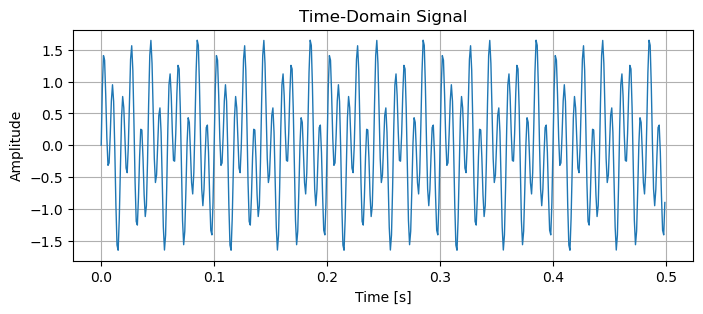

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
dt=0.001 # Time step
fs=1/dt # Sampling frequency [Hz]
N = 500  # Number of samples
t = np.arange(N) * dt  # Time vector

# Signal: sum of two sinusoids
f1, f2 = 50, 120  # frequencies [Hz]
x = 0.7*np.sin(2*np.pi*f1*t) + 1.0*np.sin(2*np.pi*f2*t)

# Plot time-domain signal
plt.figure(figsize=(8, 3))
plt.plot(t, x, linewidth=1)
plt.title('Time-Domain Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

---

## 3. Compute the FFT

We compute the FFT using NumPy's `np.fft.fft` function. The result is complex and contains both amplitude and phase.

The FFT returns the coefficients in DFT index order, $k=0,1,\ldots,N-1$. Directly labelling these bins gives

$$
f[k] = \frac{k}{N} f_s, \quad k = 0, 1, \dots, N-1
$$

For this example:

- $N=500$ and $\Delta t=0.001$ s
- $f_s=1/\Delta t=1000$ Hz
- $T=N\Delta t=0.5$ s
- $\Delta f=1/T=2$ Hz

The frequencies 50 Hz and 120 Hz are exact multiples of $\Delta f$. They therefore fall exactly on FFT bins.

For even $N$, the raw FFT order is

$$
\mathbf{f}=\left[f_0,\,f_1,\,f_2,\,\ldots,\,f_{N/2-1},\,f_{-N/2},\,f_{-(N/2-1)},\,\ldots,\,f_{-1}\right],
\qquad f_k=k\Delta f.
$$


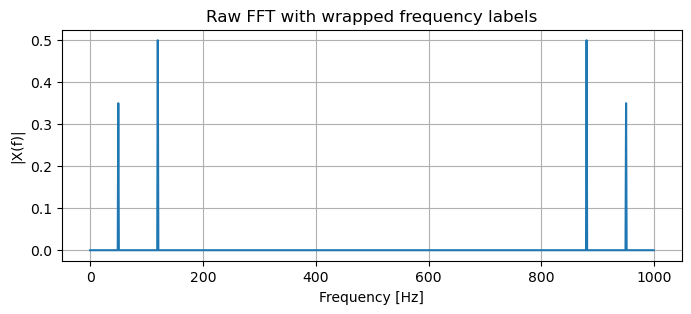

In [6]:
# Compute FFT
X = 1/N*np.fft.fft(x)

# Wrapped frequency labels following the raw FFT bin order
f_wrapped = np.arange(N) * fs / N

# Plot the non-shifted FFT
plt.figure(figsize=(8,3))
plt.plot(f_wrapped, np.abs(X))
plt.title('Raw FFT with wrapped frequency labels')
plt.xlabel('Frequency [Hz]')
plt.ylabel('|X(f)|')
plt.grid(True)


We see the expected peaks at 50 Hz and 120 Hz, but the wrapped frequency labels also place peaks at $f_s-50=950$ Hz and $f_s-120=880$ Hz. These are not new physical high-frequency components. A real-valued sinusoid contains a pair of complex Fourier components at $+f$ and $-f$. Because discrete-time frequency is periodic modulo $f_s$, the negative frequency $-f$ occupies the raw DFT bin labelled $f_s-f$ by the wrapped axis above.

Thus, the raw FFT values are correct, but interpreting every bin label between 0 and $f_s$ as a positive physical frequency is misleading. To obtain a signed frequency axis in increasing order, we shift both the FFT coefficients and their frequency coordinates.

---

## 4. Understanding FFT Shift

The raw FFT order is:

1. Zero frequency
2. Positive frequencies
3. Negative frequencies

`fftshift` rearranges this to increasing signed frequency:

$$
\left[f_{-N/2},\ldots,f_{-1},f_0,f_1,\ldots,f_{N/2-1}\right].
$$

For even $N$, this axis runs from $-f_s/2$ to $f_s/2-\Delta f$.

```python
X_shifted = np.fft.fftshift(X)
f_shifted = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
```

The coefficients are unchanged; only their order changes.

For the inverse transform, `ifft` expects raw FFT order. Apply `ifftshift` first when the spectrum is centered.

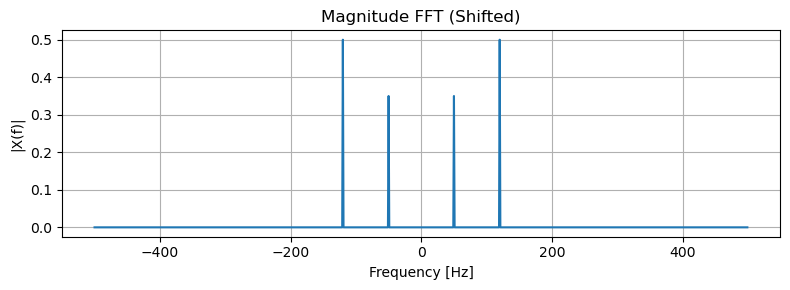

In [7]:
# Shift FFT and frequency vector
X_shifted = np.fft.fftshift(X)
f_shifted = np.fft.fftshift(np.fft.fftfreq(N,d=dt))

# Plot shifted FFT
plt.figure(figsize=(8,3))
plt.plot(f_shifted, np.abs(X_shifted))
plt.title('Magnitude FFT (Shifted)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('|X(f)|')
plt.grid(True)
plt.tight_layout()
plt.show()


---

## 5. Comparison of Shifted vs Non-Shifted FFT

To clearly see the difference, let's plot both versions side by side.


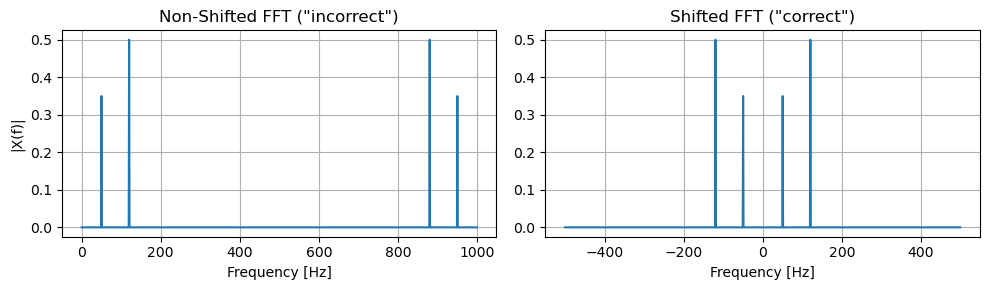

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Non-shifted
axes[0].plot(f_wrapped, np.abs(X))
axes[0].set_title('Raw FFT: misleading frequency labels')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('|X(f)|')
axes[0].grid(True)

# Shifted
axes[1].plot(f_shifted, np.abs(X_shifted))
axes[1].set_title('Shifted FFT: signed frequency axis')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].grid(True)

plt.tight_layout()
plt.show()


---

## 6. Recipes

### From the time domain to the frequency domain

1. Create $N$ samples on $0\leq t<T$, where $T=N\Delta t$.
2. Compute the FFT, scale it by $1/N$, and create its frequency vector. Both are initially in raw FFT order.
3. Apply `fftshift` to both arrays when a frequency axis from negative to positive frequency is desired.

```python
t = np.arange(N) * dt
X = np.fft.fft(x) / N
f = np.fft.fftfreq(N, d=dt)

f_centered = np.fft.fftshift(f)
X_centered = np.fft.fftshift(X)
```

### From the frequency domain to the time domain

1. Create a centered frequency vector and define $X(f)$ from negative to positive frequency. For a real time series, require $X(-f)=X(f)^*$.

   $$
   \mathbf{f}_{\text{centered}}=\left[f_{-N/2},\ldots,f_{-1},f_0,f_1,\ldots,f_{N/2-1}\right].
   $$

2. Apply `ifftshift` to put the coefficients into the raw FFT order expected by `ifft`.
3. Apply the inverse FFT. Multiply by $N$ because the forward FFT was scaled by $1/N$.

```python
f_centered = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
X_centered = ...  # Define X(f) on the centered frequency vector

X = np.fft.ifftshift(X_centered)
x = N * np.fft.ifft(X)
x = np.real_if_close(x)
```
